SV Model Creation (Original and Distilled)

[1] Extraction of starting model data in raw data saving all in the session [~6GB]

In [ ]:
!wget https://www.openslr.org/resources/12/train-clean-100.tar.gz
!tar -xzf train-clean-100.tar.gz
!rm train-clean-100.tar.gz
!ls LibriSpeech/train-clean-100/

[2] MFE Audio Processing (From 1 sec 16000 Hz raw data -> Log-Mel Spectrogram)

In [ ]:
import os
import numpy as np
import librosa
from tqdm import tqdm

# Constants definition
SAMPLE_RATE = 16000
FRAME_SIZE = 512
HOP_LENGTH = 384
N_FFT = 512
N_MELS = 40
PRE_EMPHASIS_COEFF = 0.96785

# Extracting from the previous download file

def load_metadata(input_dir):
    """Load both speaker and chapter metadata"""
    # Load speaker info
    speaker_info = {}
    speaker_file = os.path.join(input_dir, "..", "speaker.txt")  # One level up from train-clean-100
    if os.path.exists(speaker_file):
        with open(speaker_file, 'r') as f:
            for line in f:
                if line.strip():
                    parts = [p.strip() for p in line.split('|')]
                    speaker_id = parts[0]
                    speaker_info[speaker_id] = {
                        'sex': parts[1],
                        'subset': parts[2],
                        'minutes': float(parts[3]),
                        'name': parts[4]
                    }

    # Load chapter info
    chapter_info = {}
    chapter_file = os.path.join(input_dir, "..", "chapters.txt")  # One level up from train-clean-100
    if os.path.exists(chapter_file):
        with open(chapter_file, 'r') as f:
            for line in f:
                if line.strip():
                    parts = [p.strip() for p in line.split('|')]
                    chapter_id = parts[0]
                    chapter_info[chapter_id] = {
                        'reader': parts[1],
                        'minutes': float(parts[2]),
                        'subset': parts[3],
                        'project_id': parts[4],
                        'book_id': parts[5],
                        'chapter_title': parts[6],
                        'project_title': parts[7]
                    }

    return speaker_info, chapter_info

# Pre-emphasis function
def apply_pre_emphasis(y, coeff=PRE_EMPHASIS_COEFF):
    """Apply pre-emphasis matching your C implementation"""
    emphasized = np.zeros_like(y, dtype=np.float32)
    emphasized[0] = y[0]
    for i in range(1, len(y)):
        emphasized[i] = y[i] - coeff * y[i-1]
    return emphasized

# Function that performs the actual MFE Block
def extract_mfe_segmented(audio_path, segment_sec=1.0, target_frames=None):
    """Extract 1-second segmented MFEs (pad/truncate to target_frames if specified)"""
    # 1. Audio Loading and Normalization
    y, sr = librosa.load(audio_path, sr=SAMPLE_RATE)
    y = y / np.max(np.abs(y))

    # 2. Pre-emphasis function
    y_emphasized = apply_pre_emphasis(y)

    # 3. Number of frames calculus
    hop_samples = HOP_LENGTH
    frames_per_segment = int(segment_sec * SAMPLE_RATE / hop_samples)

    # 4. To each frame...
    mfe_segments = []
    for start_idx in range(0, len(y_emphasized), SAMPLE_RATE):  # Jump by 1-second intervals
        end_idx = start_idx + SAMPLE_RATE
        if end_idx > len(y_emphasized):
            break  # Discard incomplete segment

        # 4.1 Extract segment
        segment = y_emphasized[start_idx:end_idx]

        # 4.2 Compute Fast Fourier Transform
        stft = librosa.stft(
            segment,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            win_length=FRAME_SIZE,
            window='hamming'
        )
        # 4.3 Magnitude of Frequency
        spectrogram = np.abs(stft)

        # 4.4 Convert to dB and normalize
        spectrogram = 10 * np.log10(spectrogram**2 + 1e-20)
        spectrogram = np.maximum(spectrogram, -50)
        spectrogram = (spectrogram + 50) / 62

        # 4.5 Creation of Matrix of Mel scaling
        mel_basis = librosa.filters.mel(
            sr=SAMPLE_RATE,
            n_fft=N_FFT,
            n_mels=N_MELS,
            fmin=0,
            fmax=8000
        )
        # 4.6 Scalar Prodoct between dB-Spectrogram and Mele Convertion
        mfe = np.dot(mel_basis, spectrogram)

        # 4.7 Pad/truncate if target_frames is specified
        if target_frames:
            if mfe.shape[1] < target_frames:
                mfe = np.pad(mfe, ((0, 0), (0, target_frames - mfe.shape[1])))
            else:
                mfe = mfe[:, :target_frames]

        mfe_segments.append(mfe.T)  # Transpose to (time, mel) [40]

    return mfe_segments # [40x40]

# Main Workflow to process raw data
def process_librispeech_segmented(input_dir, output_path, min_samples=1448, segment_sec=1.0):
    """Process dataset with 1-second segmentation"""
    samples = []
    classes = []
    speaker_info, chapter_info = load_metadata(input_dir)
    speaker_counts = {}

    # 1. Count valid segments per speaker because each speaker should have <min_samples>
    print("Counting segments per speaker...")
    for root, _, files in os.walk(input_dir):
        parts = root.split(os.sep)
        if len(parts) >= 3 and parts[-2].isdigit() and parts[-1].isdigit():
            speaker_id = parts[-2]
            for file in files:
                if file.endswith('.flac'):
                    audio_path = os.path.join(root, file)
                    y, sr = librosa.load(audio_path, sr=SAMPLE_RATE)
                    num_segments = int(len(y) / SAMPLE_RATE)  # Full 1-second segments
                    speaker_counts[speaker_id] = speaker_counts.get(speaker_id, 0) + num_segments

    # 2. Filter speakers with enough segments
    valid_speakers = {spk: cnt for spk, cnt in speaker_counts.items() if cnt >= min_samples}
    speaker_ids = {spk: idx for idx, spk in enumerate(sorted(valid_speakers.keys()))}

    print(f"Processing {len(valid_speakers)} speakers with ≥{min_samples} segments...")

    # 3. Segments Extraction
    for speaker in tqdm(valid_speakers):
        processed_segments = 0
        speaker_path = os.path.join(input_dir, speaker)

        for root, _, files in os.walk(speaker_path):
            for file in sorted(files):
                if file.endswith('.flac') and processed_segments < min_samples:
                    audio_path = os.path.join(root, file)

                    #3.1 Processing the audio segment to spectrogram
                    mfe_segments = extract_mfe_segmented(audio_path, segment_sec=segment_sec)

                    #3.2 Association of the spectrogram to a class for labeling
                    for mfe in mfe_segments:
                        if processed_segments >= min_samples:
                            break
                        samples.append(mfe)
                        classes.append(speaker_ids[speaker])
                        processed_segments += 1

    # 4. Save as NPZ (File already computed and saved on Github)
    samples = np.array(samples, dtype=np.float32)
    classes = np.array(classes, dtype=np.int32)

    np.savez_compressed(
        output_path,
        features=samples,  # Shape: (n_segments, 40, 40)
        speaker_labels=classes
    )
    print(f"Saved {len(samples)} segments (1s each) to {output_path}")


# Run with 1-second segmentation
process_librispeech_segmented(
    input_dir="LibriSpeech/train-clean-100",
    output_path="librispeech-train-100-clean-mfe-1sec.npz",
    min_samples=1448,
    segment_sec=1.0
)

In [52]:
import numpy as np
import random
data=np.load("librispeech-train-100-clean-mfe-1sec.npz")
X=data['features']
y=data['speaker_labels']
print("Original shape:", X.shape, y.shape)
print("Original classes:", len(np.unique(y)))
known_classes=[5, 54, 63, 20]
remaining_classes=[c for c in np.unique(y) if not c in known_classes]
unknown_classes=random.sample(remaining_classes, k=10)
mask_unknown=np.isin(y, unknown_classes)
X_unknown=X[mask_unknown]
y_unknown=y[mask_unknown]
fraction=0.3
indices=np.random.choice(len(X_unknown), size=int(len(X_unknown*fraction)), replace=False)
X_unknown=X_unknown[indices]
y_unknown=np.full(len(indices), fill_value=4)

X_known=[]
y_known=[]
for i, cls in enumerate(known_classes):
    mask=y==cls
    X_known.append(X[mask])
    y_known.append(np.full(np.sum(mask), i))
    
X_known=np.concatenate(X_known)
y_known=np.concatenate(y_known)

X_new=np.concatenate([X_known, X_unknown])
y_new=np.concatenate([y_known, y_unknown])
print("New dataset shape:", X_new.shape)
print("Class distribution:", np.unique(y_new, return_counts=True))
np.savez("filtered_sv_dataset.npz", features=X_new, speaker_labels=y_new)

Original shape: (136112, 40, 40) (136112,)
Original classes: 94
New dataset shape: (20272, 40, 40)
Class distribution: (array([0, 1, 2, 3, 4]), array([ 1448,  1448,  1448,  1448, 14480]))


In [4]:

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# 1. Set random seed
seed = 22
tf.random.set_seed(seed)
np.random.seed(seed)

def debug_data_distribution(X_train, y_train, X_val, y_val, X_test, y_test):
    """Debug function to check data distribution and potential issues."""
    print("\n" + "="*60)
    print("DATA DISTRIBUTION ANALYSIS")
    print("="*60)

    # Class distribution
    print("Class distribution:")
    print(f"Train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"Val:   {dict(zip(*np.unique(y_val, return_counts=True)))}")
    print(f"Test:  {dict(zip(*np.unique(y_test, return_counts=True)))}")

    # Value ranges
    print(f"\nData value ranges:")
    print(f"Train: min={X_train.min():.4f}, max={X_train.max():.4f}, mean={X_train.mean():.4f}")
    print(f"Val:   min={X_val.min():.4f}, max={X_val.max():.4f}, mean={X_val.mean():.4f}")
    print(f"Test:  min={X_test.min():.4f}, max={X_test.max():.4f}, mean={X_test.mean():.4f}")

    # Shapes
    print(f"\nData shapes:")
    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    # Mean activations
    train_mean = X_train.mean(axis=(1,2,3))
    val_mean = X_val.mean(axis=(1,2,3))
    print(f"\nMean activation per sample:")
    print(f"Train mean: {train_mean.mean():.4f} ± {train_mean.std():.4f}")
    print(f"Val mean:   {val_mean.mean():.4f} ± {val_mean.std():.4f}")

    # Warnings
    if len(np.unique(y_val)) != len(np.unique(y_train)):
        print("⚠️ WARNING: Validation set doesn't contain all classes!")

    if X_val.std() == 0 or X_train.std() == 0:
        print("⚠️ WARNING: Zero std detected - check your data!")

    if abs(X_train.mean() - X_val.mean()) > 0.5:
        print("⚠️ WARNING: Large mean difference between train/val sets!")

    print("="*60)

def create_balanced_dataset(shape_input, file="filtered_sv_dataset.npz",
                           values_name='features', labels_name='speaker_labels'):
    """
    Load dataset and balance classes.
    balance_strategy = 'undersample' or 'oversample'
    """
    if len(shape_input) == 3:
        height, width, channels = shape_input
    elif len(shape_input) == 2:
        height, width = shape_input
        channels = 1
    else:
        raise ValueError("Shape Input must be (h, w) or (h, w, c).")

    # Load
    dataset = np.load(file)
    samples = dataset[values_name][:, :height, :width]
    classes = dataset[labels_name].astype(int)
    unique_classes = np.unique(classes)

    print(f"Original dataset: {samples.shape}, classes: {unique_classes}")
    print(f"Original class distribution: {dict(zip(*np.unique(classes, return_counts=True)))}")
    # Split
    X_temp, X_test, y_temp, y_test = train_test_split(
        samples, classes, test_size=0.2, stratify=classes, random_state=seed
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=seed
    )

    if channels == 1:
        X_train = np.expand_dims(X_train, -1)
        X_val = np.expand_dims(X_val, -1)
        X_test = np.expand_dims(X_test, -1)

    # Debug
    debug_data_distribution(X_train, y_train, X_val, y_val, X_test, y_test)

    return X_train, y_train, X_val, y_val, X_test, y_test, len(unique_classes)

# === Example usage ===
shape_input = (40, 40, 1)
X_train, y_train, X_val, y_val, X_test, y_test, n_classes = create_balanced_dataset(
    shape_input
)
class_names=np.unique(y_test)
class_names = [f"sp_{i+1}" for i in range(len(class_names)-1)] + ["unknown"]
print("Class Names: ", class_names)
print("Num classes:", n_classes)
X_train=X_train.reshape(X_train.shape[0], -1)
X_val=X_val.reshape(X_val.shape[0], -1)
X_test=X_test.reshape(X_test.shape[0], -1)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Original dataset: (20272, 40, 40), classes: [0 1 2 3 4]
Original class distribution: {0: 1448, 1: 1448, 2: 1448, 3: 1448, 4: 14480}

DATA DISTRIBUTION ANALYSIS
Class distribution:
Train: {0: 868, 1: 868, 2: 869, 3: 869, 4: 8688}
Val:   {0: 290, 1: 290, 2: 289, 3: 290, 4: 2896}
Test:  {0: 290, 1: 290, 2: 290, 3: 289, 4: 2896}

Data value ranges:
Train: min=0.0000, max=1.0000, mean=0.3139
Val:   min=0.0000, max=1.0000, mean=0.3137
Test:  min=0.0000, max=1.0000, mean=0.3130

Data shapes:
Train: (12162, 40, 40, 1), Val: (4055, 40, 40, 1), Test: (4055, 40, 40, 1)

Mean activation per sample:
Train mean: 0.3139 ± 0.1199
Val mean:   0.3137 ± 0.1194
Class Names:  ['sp_1', 'sp_2', 'sp_3', 'sp_4', 'unknown']
Num classes: 5
Train: (12162, 1600), Val: (4055, 1600), Test: (4055, 1600)


[3] Speaker Verification Model Convolutional Version Training

2.16.2


Model: "kws_dense_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,725 (2.07 MB)

 Trainable params: 542,725 (2.07 MB)

...

381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.6760 - f1_score: 0.6550 - loss: 105.6108 - val_accuracy: 0.7309 - val_f1_score: 0.7304 - val_loss: 126.2835 - learning_rate: 0.0010
Epoch 18/300
380/381 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6932 - f1_score: 0.6697 - loss: 94.1035
Epoch 18: val_f1_score did not improve from 0.73038
381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.6831 - f1_score: 0.6654 - loss: 93.8846 - val_accuracy: 0.6927 - val_f1_score: 0.7060 - val_loss: 194.8469 - learning_rate: 0.0010
Epoch 19/300
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6631 - f1_score: 0.6508 - loss: 136.6378
Epoch 19: val_f1_score did not improve from 0.73038
381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.6715 - f1_score: 0.6595 - loss: 124.5746 - val_accuracy: 0.6779 - val_f1_score: 0.7126 - val_loss: 163.8132 - learning_rate: 0.0010
Epoch 20/300
380/381 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6851 - f1_score: 0.6654 - loss: 123.5659
E

381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.6868 - f1_score: 0.6648 - loss: 154.4054 - val_accuracy: 0.8032 - val_f1_score: 0.7389 - val_loss: 166.7149 - learning_rate: 0.0010
Epoch 22/300
380/381 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6978 - f1_score: 0.6755 - loss: 148.4722
Epoch 22: val_f1_score did not improve from 0.73891
381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.6921 - f1_score: 0.6705 - loss: 153.1281 - val_accuracy: 0.4792 - val_f1_score: 0.5518 - val_loss: 626.3859 - learning_rate: 0.0010
Epoch 23/300
380/381 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6783 - f1_score: 0.6652 - loss: 170.8707
Epoch 23: val_f1_score did not improve from 0.73891
381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.6898 - f1_score: 0.6680 - loss: 172.1593 - val_accuracy: 0.6501 - val_f1_score: 0.6747 - val_loss: 373.5477 - learning_rate: 0.0010
Epoch 24/300
380/381 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6523 - f1_score: 0.6464 - loss: 282.6751

381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.6999 - f1_score: 0.6849 - loss: 189.2867 - val_accuracy: 0.7273 - val_f1_score: 0.7427 - val_loss: 289.3415 - learning_rate: 0.0010
Epoch 28/300
380/381 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7084 - f1_score: 0.6952 - loss: 167.4145
Epoch 28: val_f1_score did not improve from 0.74274
381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.7078 - f1_score: 0.6922 - loss: 189.4307 - val_accuracy: 0.6219 - val_f1_score: 0.6344 - val_loss: 647.3113 - learning_rate: 0.0010
Epoch 29/300
380/381 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6900 - f1_score: 0.6739 - loss: 243.6954
Epoch 29: val_f1_score did not improve from 0.74274
381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.6939 - f1_score: 0.6837 - loss: 223.3843 - val_accuracy: 0.6801 - val_f1_score: 0.6680 - val_loss: 448.9437 - learning_rate: 0.0010
Epoch 30/300
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7041 - f1_score: 0.6837 - loss: 255.1063

381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.7094 - f1_score: 0.6953 - loss: 249.9342 - val_accuracy: 0.7314 - val_f1_score: 0.7506 - val_loss: 234.2227 - learning_rate: 0.0010
Epoch 32/300
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6993 - f1_score: 0.6914 - loss: 271.1472
Epoch 32: val_f1_score did not improve from 0.75057
381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.7000 - f1_score: 0.6910 - loss: 276.6281 - val_accuracy: 0.6375 - val_f1_score: 0.7217 - val_loss: 584.6157 - learning_rate: 0.0010
Epoch 33/300
380/381 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6982 - f1_score: 0.6844 - loss: 299.9448
Epoch 33: val_f1_score improved from 0.75057 to 0.79406, saving model to best_f1_sv_model.h5


381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.6991 - f1_score: 0.6851 - loss: 297.4929 - val_accuracy: 0.8444 - val_f1_score: 0.7941 - val_loss: 173.8359 - learning_rate: 0.0010
Epoch 34/300
380/381 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7176 - f1_score: 0.7067 - loss: 300.2830
Epoch 34: val_f1_score did not improve from 0.79406
381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.7065 - f1_score: 0.6959 - loss: 303.9898 - val_accuracy: 0.6582 - val_f1_score: 0.7107 - val_loss: 575.7091 - learning_rate: 0.0010
Epoch 35/300
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7152 - f1_score: 0.6944 - loss: 314.6758
Epoch 35: val_f1_score did not improve from 0.79406
381/381 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.7050 - f1_score: 0.6902 - loss: 309.3905 - val_accuracy: 0.6168 - val_f1_score: 0.7075 - val_loss: 607.7228 - learning_rate: 0.0010
Epoch 36/300
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7090 - f1_score: 0.6977 - loss: 330.0702

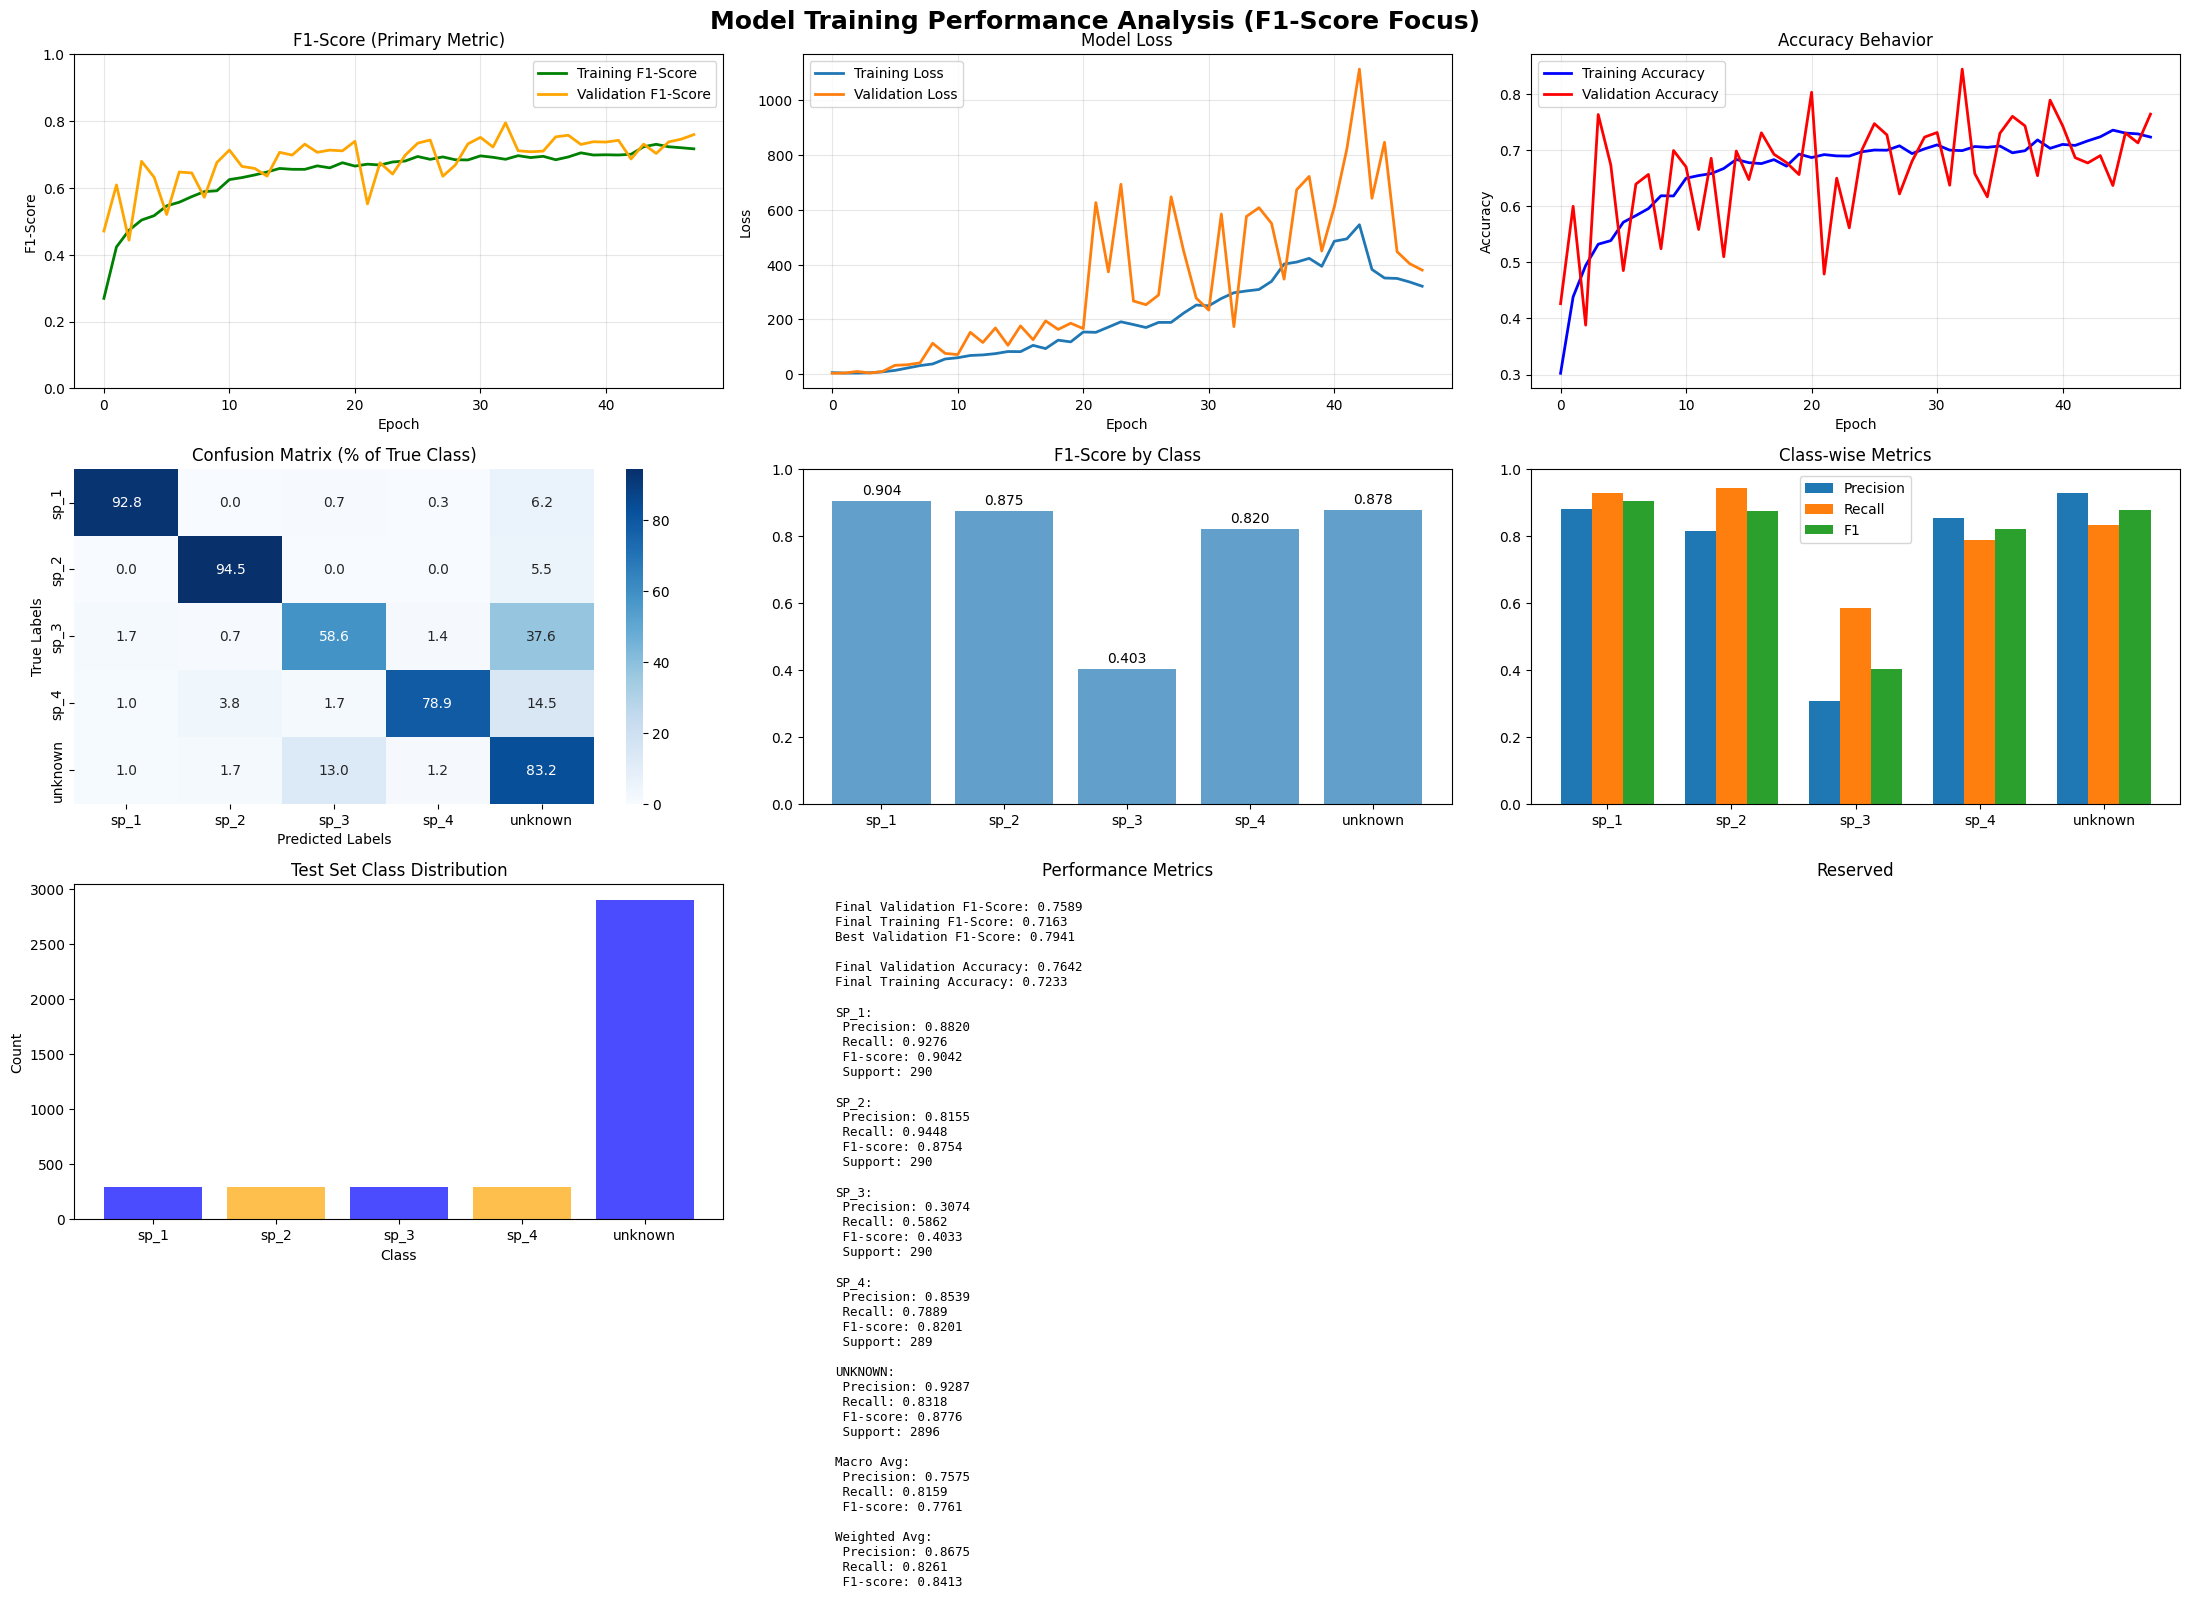

TRAINING SUMMARY (F1-Score Focus)
Total epochs trained: 48
Final training F1-score: 0.7163
Final validation F1-score: 0.7589
Best validation F1-score: 0.7941
Final training accuracy: 0.7233
Final validation accuracy: 0.7642
Final training loss: 321.3112
Final validation loss: 380.1333

Test Set Performance:
              precision    recall  f1-score   support

        sp_1       0.88      0.93      0.90       290
        sp_2       0.82      0.94      0.88       290
        sp_3       0.31      0.59      0.40       290
        sp_4       0.85      0.79      0.82       289
     unknown       0.93      0.83      0.88      2896

    accuracy                           0.83      4055
   macro avg       0.76      0.82      0.78      4055
weighted avg       0.87      0.83      0.84      4055


Overall Weighted F1-Score on Test Set: 0.8413
Model saved successfully!


In [5]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import shutil
import numpy as np
import tensorflow as tf
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import seaborn as sns

import subprocess
import os
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

import shutil
tfk = tf.keras
tfkl = tf.keras.layers
print(tf.__version__)

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

class F1Score(tf.keras.metrics.Metric):
    def __init__(self, num_classes, average="macro", name="f1_score", **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.average = average

        # Store per-class statistics
        self.tp = self.add_weight(name="tp", shape=(num_classes,), initializer="zeros")
        self.fp = self.add_weight(name="fp", shape=(num_classes,), initializer="zeros")
        self.fn = self.add_weight(name="fn", shape=(num_classes,), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Convert predictions and labels to class indices
        y_pred = tf.argmax(y_pred, axis=1)
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)

        # One-hot encode labels for per-class calculations
        y_true_oh = tf.one_hot(y_true, depth=self.num_classes)
        y_pred_oh = tf.one_hot(y_pred, depth=self.num_classes)

        tp = tf.reduce_sum(y_true_oh * y_pred_oh, axis=0)
        fp = tf.reduce_sum((1 - y_true_oh) * y_pred_oh, axis=0)
        fn = tf.reduce_sum(y_true_oh * (1 - y_pred_oh), axis=0)

        self.tp.assign_add(tf.cast(tp, self.tp.dtype))
        self.fp.assign_add(tf.cast(fp, self.fp.dtype))
        self.fn.assign_add(tf.cast(fn, self.fn.dtype))

    def result(self):
        precision = self.tp / (self.tp + self.fp + 1e-7)
        recall = self.tp / (self.tp + self.fn + 1e-7)
        f1 = 2 * precision * recall / (precision + recall + 1e-7)

        if self.average == "macro":
            return tf.reduce_mean(f1)
        elif self.average == "weighted":
            weights = self.tp + self.fn
            return tf.reduce_sum(f1 * weights) / (tf.reduce_sum(weights) + 1e-7)
        else:  # "none" → return vector of per-class F1s
            return f1

    def reset_state(self):
        self.tp.assign(tf.zeros_like(self.tp))
        self.fp.assign(tf.zeros_like(self.fp))
        self.fn.assign(tf.zeros_like(self.fn))

def create_cnn_sv_model(input_shape, n_classes):

  input_layer = tfkl.Input(shape=input_shape,
                           name='input')
  x=tfkl.BatchNormalization()(input_layer)
  x = tfkl.Conv2D(
              filters=8,
              kernel_size=(3, 3),
              strides = (1, 1),
              padding = 'same',
              input_shape=input_shape,
              use_bias = True,
              data_format = 'channels_last',
              kernel_initializer = tfk.initializers.GlorotUniform(seed)
    )(x)
  x=tfkl.MaxPooling2D(pool_size=(3, 3), padding="valid")(x)
  x = tfkl.Conv2D(
              filters=16,
              kernel_size=(3, 3),
              strides = (1, 1),
              padding = 'same',
              input_shape=input_shape,
              use_bias = True,
              data_format = 'channels_last',
              kernel_initializer = tfk.initializers.GlorotUniform(seed)
    )(x)

  x=tfkl.MaxPooling2D(pool_size=(2, 2), padding="valid")(x)

  x = tfkl.Conv2D(
              filters=32,
              kernel_size=(3, 3),
              strides = (2, 2),
              padding = 'same',
              input_shape=input_shape,
              use_bias = True,
              data_format = 'channels_last',
              kernel_initializer = tfk.initializers.GlorotUniform(seed)
    )(x)
  
  x = tfkl.Conv2D(
              filters=64,
              kernel_size=(3, 3),
              strides = (2, 2),
              padding = 'same',
              input_shape=input_shape,
              use_bias = True,
              data_format = 'channels_last',
              kernel_initializer = tfk.initializers.GlorotUniform(seed)
    )(x)

  x = tfkl.Flatten()(x)

  x = tfkl.Dense(
                units=128,
                kernel_initializer=tfk.initializers.GlorotUniform(seed),
                use_bias = True,
                name='fully_connected')(x)
  
  x = tfkl.Dense(
                units=64,
                kernel_initializer=tfk.initializers.GlorotUniform(seed),
                use_bias = True,
                name='fully_connected_2')(x)

  outputs = tfkl.Dense(
                    units=n_classes,
                    activation='softmax',
                    kernel_initializer=tfk.initializers.GlorotUniform(seed),
                    use_bias = True,
                    name='output_layer')(x)

  model = tfk.Model(inputs=input_layer, outputs=outputs, name='teacher_sv_cnn_model')
  
  optimizer = tfk.optimizers.Adam(learning_rate=0.001)
  model.compile(loss=tfk.losses.SparseCategoricalCrossentropy(),
                optimizer=optimizer,
                metrics=['accuracy', F1Score(n_classes)]
  )
  return model

def build_student_model(input_shape, num_classes=2):
    """Your exact target architecture - simple 3-layer dense network"""
    inputs = tf.keras.Input(shape=input_shape, name="input")  # Already flattened input (1600,)

    x = tf.keras.layers.Dense(256, activation="relu", name="dense_1")(inputs)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Dense(256, activation="relu", name="dense_2")(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Dense(256, activation="relu", name="dense_3")(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="output")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="kws_dense_model")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy', F1Score(n_classes)]
    )
    return model

# Function to calculate precision, recall, F1 for each class
def calculate_precision_recall_f1(y_true, y_pred, class_names):
    """Calculate precision, recall, and F1 for each class"""
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    
    results = {}
    for i, class_name in enumerate(class_names):
        results[class_name] = {
            'precision': precision[i],
            'recall': recall[i],
            'f1': f1[i],
            'support': support[i]
        }
    
    return results

def plot_training_performance(history, model, X_test, y_test, class_names, y_train=None, y_val=None, y_test_labels=None):
    """Create comprehensive graphs showing training performance with F1-score, accuracy, and sample counts"""

    # Get predictions
    y_pred_proba = model.predict(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    # Convert one-hot encoded y_test to class indices if needed
    if len(y_test.shape) > 1:
        y_true = np.argmax(y_test, axis=1)
    else:
        y_true = y_test
    
    # Calculate precision, recall, F1 for each class
    metrics = calculate_precision_recall_f1(y_true, y_pred, class_names)
    
    # Create figure with more subplots (3x3 grid now)
    fig, axes = plt.subplots(3, 3, figsize=(22, 16))
    fig.suptitle('Model Training Performance Analysis (F1-Score Focus)', fontsize=18, fontweight='bold')
    
    # 1. F1-Score plot
    if 'f1_score' in history.history:
        axes[0, 0].plot(history.history['f1_score'], label='Training F1-Score', linewidth=2, color='green')
        axes[0, 0].plot(history.history['val_f1_score'], label='Validation F1-Score', linewidth=2, color='orange')
        axes[0, 0].set_title('F1-Score (Primary Metric)')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('F1-Score')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].set_ylim(0, 1)

    # 2. Loss plot
    axes[0, 1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Accuracy plot
    axes[0, 2].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
    axes[0, 2].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
    axes[0, 2].set_title('Accuracy Behavior')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Accuracy')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1, 0])
    axes[1, 0].set_title('Confusion Matrix (% of True Class)')
    axes[1, 0].set_xlabel('Predicted Labels')
    axes[1, 0].set_ylabel('True Labels')
    
    # 5. F1-Score by class
    class_f1_scores = [metrics[c]['f1'] for c in class_names]
    bars = axes[1, 1].bar(range(len(class_names)), class_f1_scores, alpha=0.7)
    axes[1, 1].set_title('F1-Score by Class')
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].set_xticks(range(len(class_names)))
    axes[1, 1].set_xticklabels(class_names)
    for bar, value in zip(bars, class_f1_scores):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{value:.3f}', ha='center', va='bottom')
    
    # 6. Precision-Recall-F1 grouped bars
    precision_values = [metrics[c]['precision'] for c in class_names]
    recall_values = [metrics[c]['recall'] for c in class_names]
    f1_values = [metrics[c]['f1'] for c in class_names]
    width = 0.25
    idx = np.arange(len(class_names))
    axes[1, 2].bar(idx - width, precision_values, width, label="Precision")
    axes[1, 2].bar(idx, recall_values, width, label="Recall")
    axes[1, 2].bar(idx + width, f1_values, width, label="F1")
    axes[1, 2].set_title('Class-wise Metrics')
    axes[1, 2].set_xticks(idx)
    axes[1, 2].set_xticklabels(class_names)
    axes[1, 2].legend()
    axes[1, 2].set_ylim(0, 1)
    
    # 7. Sample counts (stacked)
    unique, counts = np.unique(y_true, return_counts=True)
    axes[2, 0].bar(unique, counts, color=['blue', 'orange'], alpha=0.7)
    axes[2, 0].set_title('Test Set Class Distribution')
    axes[2, 0].set_xlabel('Class')
    axes[2, 0].set_ylabel('Count')
    axes[2, 0].set_xticks(unique)
    axes[2, 0].set_xticklabels(class_names)
    
    # 8. Text metrics summary
    metrics_text = ""
    if 'val_f1_score' in history.history: 
        metrics_text += f"Final Validation F1-Score: {history.history['val_f1_score'][-1]:.4f}\n" 
        metrics_text += f"Final Training F1-Score: {history.history['f1_score'][-1]:.4f}\n" 
        metrics_text += f"Best Validation F1-Score: {max(history.history['val_f1_score']):.4f}\n\n" 
    metrics_text += f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}\n" 
    metrics_text += f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}\n\n" 
    
    for c in class_names: 
        class_label= str(c).upper()
        metrics_text += f"{class_label}:\n"
        metrics_text += f" Precision: {metrics[c]['precision']:.4f}\n" 
        metrics_text += f" Recall: {metrics[c]['recall']:.4f}\n" 
        metrics_text += f" F1-score: {metrics[c]['f1']:.4f}\n" 
        metrics_text += f" Support: {metrics[c]['support']}\n\n" 

    # Macro/weighted
    macro_precision = np.mean([metrics[c]['precision'] for c in class_names]) 
    macro_recall = np.mean([metrics[c]['recall'] for c in class_names]) 
    macro_f1 = np.mean([metrics[c]['f1'] for c in class_names]) 
    total_support = sum([metrics[c]['support'] for c in class_names]) 
    weighted_precision = sum([metrics[c]['precision'] * metrics[c]['support'] for c in class_names]) / total_support 
    weighted_recall = sum([metrics[c]['recall'] * metrics[c]['support'] for c in class_names]) / total_support 
    weighted_f1 = sum([metrics[c]['f1'] * metrics[c]['support'] for c in class_names]) / total_support 
    
    metrics_text += f"Macro Avg:\n Precision: {macro_precision:.4f}\n Recall: {macro_recall:.4f}\n F1-score: {macro_f1:.4f}\n\n"
    metrics_text += f"Weighted Avg:\n Precision: {weighted_precision:.4f}\n Recall: {weighted_recall:.4f}\n F1-score: {weighted_f1:.4f}" 
    
    axes[2, 1].text(0.05, 0.95, metrics_text, transform=axes[2, 1].transAxes, 
                    fontfamily='monospace', verticalalignment='top', fontsize=9) 
    axes[2, 1].set_title('Performance Metrics') 
    axes[2, 1].set_axis_off()
    
    # 9. Reserved slot
    axes[2, 2].axis("off")
    axes[2, 2].set_title("Reserved")
    
    plt.tight_layout()
    plt.show()
    
    # Print training summary with F1-score focus
    print("=" * 60)
    print("TRAINING SUMMARY (F1-Score Focus)")
    print("=" * 60)
    print(f"Total epochs trained: {len(history.history['loss'])}")
    if 'f1_score' in history.history:
        print(f"Final training F1-score: {history.history['f1_score'][-1]:.4f}")
        print(f"Final validation F1-score: {history.history['val_f1_score'][-1]:.4f}")
        print(f"Best validation F1-score: {max(history.history['val_f1_score']):.4f}")
    print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"Final training loss: {history.history['loss'][-1]:.4f}")
    print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")
    
    print("\nTest Set Performance:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Calculate and display overall F1-score
    overall_f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"\nOverall Weighted F1-Score on Test Set: {overall_f1:.4f}")
    
    return fig

# 5. Setting the enviroonment for training
def main():
    spectrogram_size=(1600,)
    #spectrogram_size=(40, 40, 1)
    batch_size=32
    model=build_student_model(spectrogram_size, n_classes)
    #model=create_cnn_sv_model(spectrogram_size, n_classes)
    model.summary()

    class_weights = compute_class_weight('balanced', 
                                    classes=np.unique(y_train), 
                                    y=y_train)
    class_weight_dict = dict(enumerate(class_weights))
    print(f"Class weights for balanced training: {class_weight_dict}")

    epochs = 300

    # Enhanced callbacks with F1-score monitoring
    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau( # Reduces learning rate based on F1-score
            monitor="val_f1_score", factor=0.5, patience=10, verbose=1, mode='max'
        ),
        tf.keras.callbacks.EarlyStopping( # Early stopping based on F1-score
            monitor="val_f1_score", patience=15, restore_best_weights=True, mode='max', verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint( # Save best model based on F1-score
            'best_f1_sv_model.h5', monitor='val_f1_score',
            save_best_only=True, mode='max', verbose=1
        )
    ]

    print("Training Speaker Verification Model with F1-score, Precision, and Recall monitoring...")

    history = model.fit(
        X_train, y_train,
        epochs = epochs,
        batch_size=batch_size,
        validation_data = (X_val, y_val),
        class_weight = class_weight_dict,  # Add class weights for balanced training
        callbacks=callbacks,
        verbose=1
    )

    plot_training_performance(history, model, X_test, y_test, class_names, y_test_labels=class_names)

    model.save("./models/teacher_sv_cnn_model.h5")
    print("Model saved successfully!")
    
if __name__=="__main__":
    main()
